In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import joblib

In [2]:
#set to true to save output to csv
save_output = True
scaler = StandardScaler()

In [3]:
window_df = pd.read_csv("Dataset/windowedSet.csv")
print("Windowed data shape:", window_df.shape)
print(window_df.head())

Windowed data shape: (3877999, 6)
                    start_timestamp                     end_timestamp  \
0  2025-10-31 22:55:39.633569+00:00  2025-10-31 22:56:34.866330+00:00   
1  2025-10-31 22:55:47.097758+00:00  2025-10-31 22:56:43.481462+00:00   
2  2025-10-31 22:55:55.704890+00:00  2025-10-31 22:56:44.085920+00:00   
3  2025-10-31 22:55:57.455345+00:00  2025-10-31 22:56:49.837661+00:00   
4  2025-10-31 22:56:02.635641+00:00  2025-10-31 22:56:55.019935+00:00   

   dur_mean   dur_std   ts_mean    ts_std  
0  0.006682  0.000696  1.104655  1.130780  
1  0.006835  0.000620  1.139244  0.986436  
2  0.006798  0.000662  0.990660  0.775908  
3  0.006792  0.000661  1.059236  0.924353  
4  0.006831  0.000739  1.059255  0.972643  


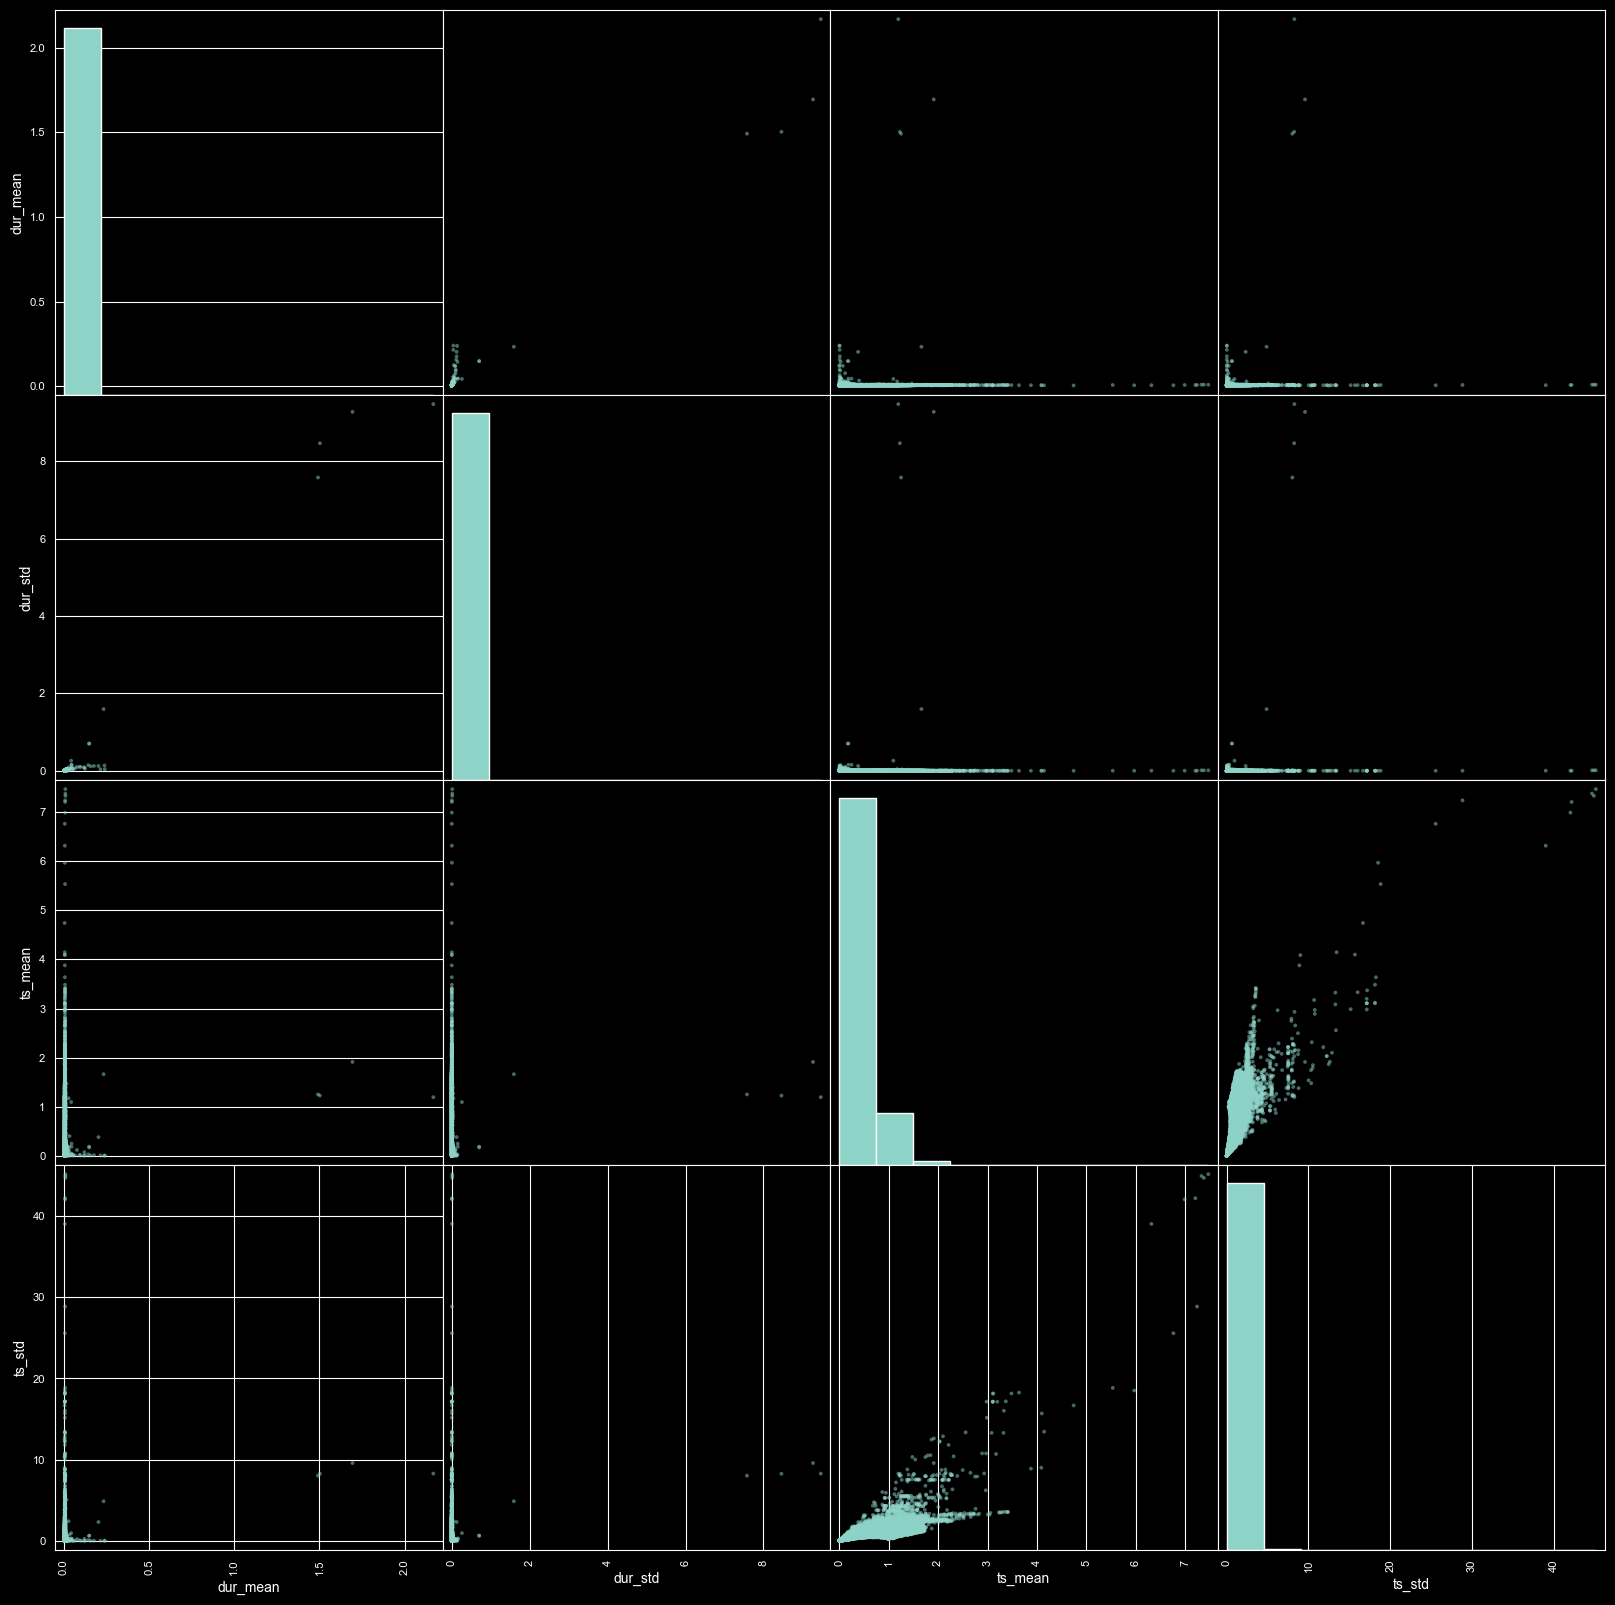

In [4]:
# Plot of samples, takes too long to plot 4M rows
sample_df = window_df.sample(n=100000)
visual = pd.plotting.scatter_matrix(sample_df, figsize = [20,20], s=30)

In [5]:
numeric_cols = []
for column in window_df.columns:
    if column not in ['start_timestamp', 'end_timestamp']:
        numeric_cols.append(column)
X_df = window_df[numeric_cols]
# Scale features
X_scaled = scaler.fit_transform(X_df)
#X_scaled = X_scaled.astype(np.float32)

Finished clustering for k = 1
Finished clustering for k = 2
Finished clustering for k = 3
Finished clustering for k = 4
Finished clustering for k = 5
Finished clustering for k = 6
Finished clustering for k = 7
Finished clustering for k = 8
Finished clustering for k = 9
Finished clustering for k = 10


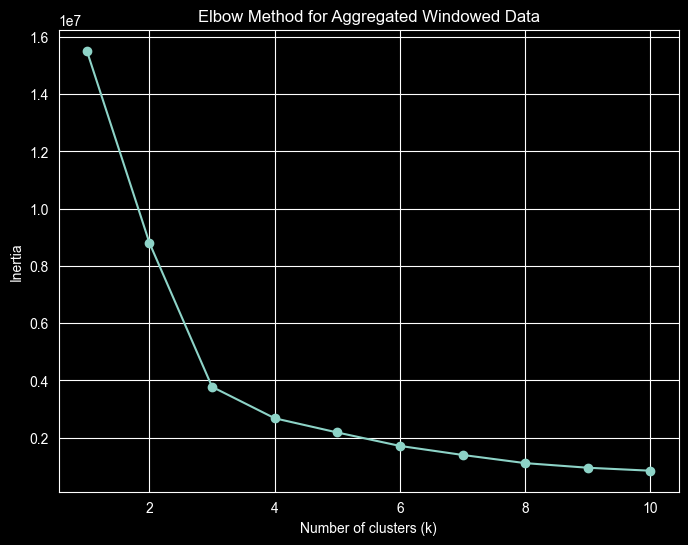

In [6]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=50)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    print("Finished clustering for k =", k)
plt.figure(figsize=(8,6))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Aggregated Windowed Data')
plt.show()

In [7]:
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, n_init=50)
window_df['cluster'] = kmeans.fit_predict(X_scaled)
if save_output:
    joblib.dump(kmeans, "Models/kmeansModel.joblib")

In [8]:
if save_output:
    window_df.to_csv("Dataset/clustering.csv", index=True)

In [9]:
'''cluster_colors = np.array([ '#0072B2',  # Blue
                            '#E69F00',  # Orange
                            '#009E73',  # Teal/Green
                            '#B33F61']) # Pink/Magenta
X_scaled_df = pd.DataFrame(X_scaled, columns=X_df.columns)

scatter_plot = pd.plotting.scatter_matrix(X_scaled_df, figsize = [10,10], c = cluster_colors[window_df['cluster']], s = 50)'''

"cluster_colors = np.array([ '#0072B2',  # Blue\n                            '#E69F00',  # Orange\n                            '#009E73',  # Teal/Green\n                            '#B33F61']) # Pink/Magenta\nX_scaled_df = pd.DataFrame(X_scaled, columns=X_df.columns)\n\nscatter_plot = pd.plotting.scatter_matrix(X_scaled_df, figsize = [10,10], c = cluster_colors[window_df['cluster']], s = 50)"

In [10]:
cluster_percentages = window_df['cluster'].value_counts(normalize=True) * 100
print("Cluster percentages:", cluster_percentages)
print("Cluster counts: ")
print(window_df['cluster'].value_counts())

Cluster percentages: cluster
0    85.148501
1    14.835924
3     0.011320
2     0.004255
Name: proportion, dtype: float64
Cluster counts: 
cluster
0    3302058
1     575337
3        439
2        165
Name: count, dtype: int64


In [11]:
#samples per cluster
sample_size = 30
sample_idx = []

# Get [sample_size] randomly selected sample IDs from each cluster, append to sample_idx
for cluster in window_df['cluster'].unique():
    cluster_points = window_df[window_df['cluster'] == cluster].index
    n = min(len(cluster_points), sample_size)
    sample_idx.extend(
        np.random.choice(cluster_points, size=n, replace=False)
    )

# Get the rows with matching IDs
sampled_df = window_df.loc[sample_idx]
if save_output:
    sampled_df.to_csv("Dataset/clustering_samples.csv", index=False)

In [12]:
from sklearn.metrics import silhouette_score
sample_size_silhouette = 50000

sample_idx_silhouette = []
for cluster in window_df['cluster'].unique():
    cluster_points = window_df[window_df['cluster'] == cluster].index
    n = min(len(cluster_points), int(sample_size_silhouette / len(window_df['cluster'].unique())))
    sample_idx_silhouette.extend(np.random.choice(cluster_points, size=n, replace=False))

X_sample = X_scaled[sample_idx_silhouette]
labels_sample = window_df['cluster'].iloc[sample_idx_silhouette]

score = silhouette_score(X_sample, labels_sample)
print("Stratified Silhouette Score (sample):", score)

Stratified Silhouette Score (sample): 0.7145806888715438
